In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from scipy import fft

%config InlineBackend.figure_formats = ['svg']
%matplotlib inline

from IPython.core.display import HTML
HTML("""
<style>
.jp-RenderedSVG{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")

# Calculating the Fourier Transform

The calculation of the Fourier transform for a known signal is performed via the definite integral:

$$
\begin{eqnarray}
\int_b^a f(x)dx & = & \Bigl[ F(x) \Bigr]_a^b \\
& =& F(b)−F(a)
\end{eqnarray}
$$

$a$ and $b$ are the lower and upper limit of the integral, respectively.
$F(x)$ is called the antiderivative of $f(x)$.
For common cases, antiderivatives can be taken from tables.

------

# Boxcar Function

The boxcar function is inherently included in many DSP calculations. It is the default window function (window functions will be introduced in detail in future sections). It is defined by a width $T$ in the time domain and an amplitude $A$. 

$$
\beta(t) = 
\begin{cases}
  A & \text{if $|t| \leq \frac{T}{2}$ } \\
  0 & \text{otherwise}
\end{cases} 
$$




To calculate the transform of the boxcar window, the integral becomes definite within the range of the window,
with the amplitude $\beta(t) = A$  within the defined interval: 
 
$$
\begin{eqnarray}
\mathcal F(\beta (t)) & = &  \int_{-\infty}^{\infty} \beta(t) e^{- j 2 \pi f t} dt \\
& = &  \int_{-T/2}^{T/2} A e^{- j 2 \pi f t} dt \\
\end{eqnarray}
$$

With the antiderivative of exponential function with a linear term in the argument

$$\int  e^{ax}dx = \frac{1}{a} e^{ax} dx $$

the definite interval becomes:

$$
\begin{eqnarray}
\mathcal F(\beta (t)) & = &  \frac{A}{-j 2 \pi  f} \Bigl[ e^{-j 2 \pi f t} \Bigr]_{-T/2}^{T/2} \\
\end{eqnarray}
$$

With the limits applied, the upper-boudary integral is subtracted from the lower-boundary integral ($a-b$):

$$
\begin{eqnarray}
\mathcal F(\beta (t)) & = &  \frac{A}{-j 2 \pi  f} \Bigl[ e^{-j \pi f T} - e^{j \pi f T} \Bigr] \\
\end{eqnarray}
$$

Rearrange and make use of Euler:


$$
\begin{eqnarray}
\mathcal F(\beta (t)) & = &  \frac{A}{\pi  f} \left[\frac{e^{-j \pi f T} - e^{j \pi f T}}{-j 2 } \right] \\
& = &  \frac{A}{\pi  f} \sin (\pi f T) \\
\end{eqnarray}
$$

Expand the fraction to get the sinc or  si function: $\mathrm{sinc}(f) = \frac{\sin(\pi f)}{\pi f}$

$$
\begin{eqnarray}
\mathcal F(\beta (t)) & =  &  AT  \frac{\sin (\pi f T)} {\pi  fT}\\
& =  &  \boxed{AT  ~ \mathrm{sinc}(f T)} \\
\end{eqnarray}
$$

-----

# Width: Time-Domain vs Frequency Domain

The Fourier transform has the width $T$ in the argument of the sinc function. Large values in the argument narrow the sinc function and increase its peak.
Hence, the wider the window, the narrower its transform and vice versa: 

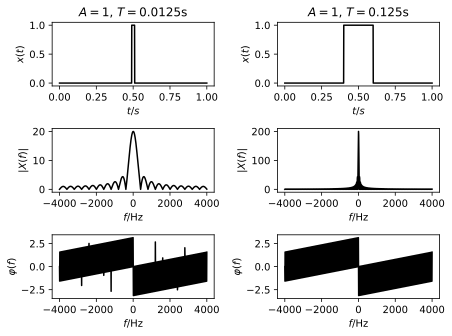

In [2]:
fs = 8000
N  = 1000
f0 = 1000
t = np.linspace(0,1,N)

x  = np.zeros(N)
x[490:510] =1
X  = fft.fftshift(fft.fft(x))

x2  = np.zeros(N)
x2[400:600] =1
X2  = fft.fftshift(fft.fft(x2))

f  = np.linspace(-fs/2,fs/2,N)
k  = np.linspace(0,N-1,N)

fig = plt.figure()

ax1 = plt.subplot(3,2,1)
ax1.set_title('$A=1$, $T=0.0125  \mathrm{s}$')
ax1.plot(t,x,'k')
ax1.set_xlabel("$t/s$");
ax1.set_ylabel("$x(t)$");

ax2 = plt.subplot(3,2,3)
ax2.plot(f,abs(X),'k')
ax2.set_xlabel("$f/\mathrm{Hz}$");
ax2.set_ylabel("$|X(f)|$");

ax3 = plt.subplot(3,2,5)
ax3.plot(f,np.angle(X),'k')
ax3.set_xlabel("$f/\mathrm{Hz}$");
ax3.set_ylabel("$\\varphi(f)$");


ax2 = plt.subplot(3,2,2)
ax2.set_title('$A=1$, $T=0.125 \mathrm{s}$')
ax2.plot(t,x2,'k')
ax2.set_xlabel("$t/s$");
ax2.set_ylabel("$x(t)$");

ax2 = plt.subplot(3,2,4)
ax2.plot(f,abs(X2),'k')
ax2.set_xlabel("$f/\mathrm{Hz}$");
ax2.set_ylabel("$|X(f)|$");

ax2 = plt.subplot(3,2,6)
ax2.plot(f,np.angle(X2),'k')
ax2.set_xlabel("$f/\mathrm{Hz}$");
ax2.set_ylabel("$\\varphi(f)$");

fig.tight_layout(pad=1)
